WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    'tau_post' is an internal variable of group 'synapses', but also exists in the run namespace with the value 20. * msecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'tau_pre' is an internal variable of group 'synapses', but also exists in the run namespace with the value 20. * msecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


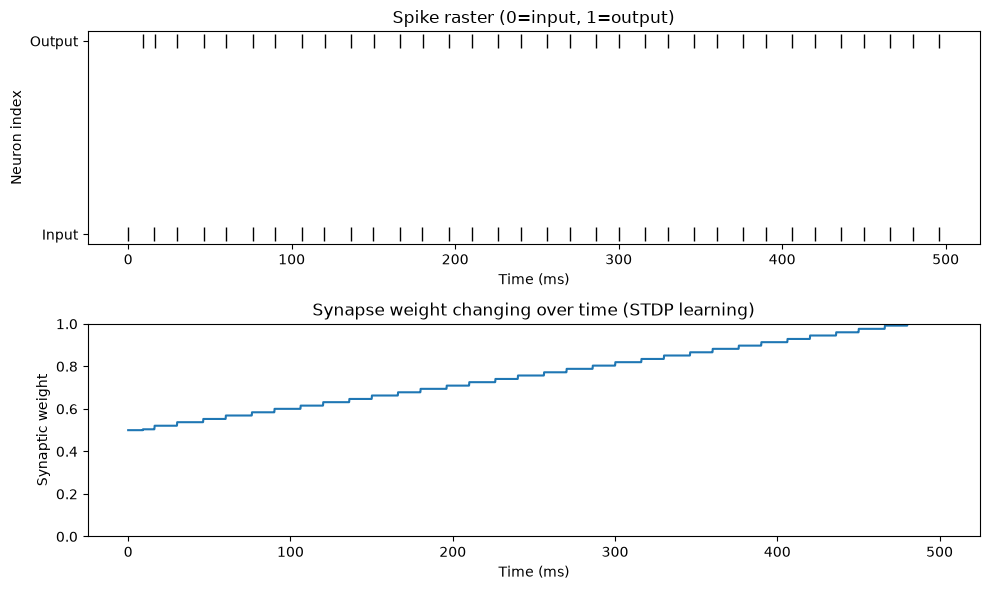

In [1]:
from brian2 import *
import matplotlib.pyplot as plt

start_scope()

# Time constant for STDP window
tau_pre = 20*ms   # how long pre-synaptic trace lasts
tau_post = 20*ms  # how long post-synaptic trace lasts

# Neuron model
eqs = '''
dv/dt = (1-v)/tau : 1
tau : second
'''

# Create two neurons - one input, one output
neurons = NeuronGroup(2, eqs, threshold='v>0.8', reset='v=0', method='exact')
neurons.tau = [10*ms, 10*ms]
neurons.v = 0

# STDP synapse rule
stdp_eqs = '''
w : 1                          # synaptic weight
dapre/dt = -apre/tau_pre : 1 (event-driven)   # pre-synaptic trace
dapost/dt = -apost/tau_post : 1 (event-driven) # post-synaptic trace
'''

on_pre = '''
v_post += w
apre += 0.01
w = clip(w + apost, 0, 1)
'''

on_post = '''
apost += 0.01
w = clip(w + apre, 0, 1)
'''

S = Synapses(neurons, neurons, stdp_eqs, on_pre=on_pre, on_post=on_post)
S.connect(i=0, j=1)  # connect neuron 0 → neuron 1
S.w = 0.5            # start with medium weight

# Drive neuron 0 to fire regularly
@network_operation(dt=30*ms)
def drive_input():
    neurons.v[0] = 1.1  # force neuron 0 to fire

# Record everything
spike_mon = SpikeMonitor(neurons)
weight_mon = StateMonitor(S, 'w', record=True)

run(500*ms)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.plot(spike_mon.t/ms, spike_mon.i, '|k', ms=10)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Neuron index')
ax1.set_title('Spike raster (0=input, 1=output)')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Input', 'Output'])

ax2.plot(weight_mon.t/ms, weight_mon.w[0])
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Synaptic weight')
ax2.set_title('Synapse weight changing over time (STDP learning)')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()